In [1]:
# libs
#import re
import pysam
import duckdb
import pandas as pd
import regex as re
import numpy as np
import itertools
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict

In [2]:
# path to ref
ref_f1 = '../references/f1_data_after_indices_two_files.fasta'
ref_p2 = '../references/p2_design.fasta'
ref_c1 = '../references/data_genomika_constrained_indexed.fasta'

# list of BAM files
bams = {
    "hp_f1": "../data/BEGONIA_2/begonia_2_trim_filter_9_mapped.bam",
    "ns_f1": "../data/BEGONIA_4/begonia_4_trim_filter_9_mapped.bam",
    "hp_p2": "../data/CAMELLIA_007/camellia_007_trim_filter_9_mapped.bam",
    "ns_p2": "../data/CAMELLIA_008/camellia_008_trim_filter_9_mapped.bam",
    "hp_c1": "../data/CAMELLIA_11/camellia_11_trim_filter_9_mapped.bam",
    "ns_c1": "../data/CAMELLIA_17/camellia_17_trim_filter_9_mapped.bam",
}

In [3]:
# tabularize alignments from BAM file
def tab_align_bam(bam_dict, out):

    # init list
    data = []
    
    # iterate over bams
    for name, bam_file in bam_dict.items():
        # open BAM file
        bam = pysam.AlignmentFile(bam_file, "rb")
        
        # process each read
        for read in bam:
            # get primary aligments
            if read.is_unmapped or read.is_secondary or read.is_supplementary:
                continue

                # extract
                row = {
                    "name": name,
                    "ref_id": bam.get_reference_name(read.reference_id),
                    "start": read.reference_start,
                    "end": read.reference_end,
                    "NM": read.get_tag("NM") if read.has_tag("NM") else None
                    }
                data.append(row)
        
        bam.close()

    df = pd.DataFrame(data)
    
    # write to parquet
    if out and not df.empty:
        df.to_parquet(out, index=False)

    #return df
    

In [4]:
# get primary alignments
tab_align_bam(
    {k: v for k, v in bams.items() if re.search(r"f1$", k)},
    out = "../results/read_stats_f1.parquet"
)
tab_align_bam(
    {k: v for k, v in bams.items() if re.search(r"p2$", k)},
    out = "../results/read_stats_p2.parquet"
)
tab_align_bam(
    {k: v for k, v in bams.items() if re.search(r"c1$", k)},
    out = "../results/read_stats_c1.parquet"
)

In [4]:
query = """
SELECT
    *,
    "end" - "start"                    AS width,
    ("end" - "start") / 140.0          AS lfrac,
    split_part(name, '_', 1)           AS prot,
    split_part(name, '_', 2)           AS pool
FROM '../results/read_stats_c1*.parquet'
"""
#FROM '../results/read_stats_[!sS]*.parquet'

con = duckdb.connect()
res_rs = con.execute(query).fetchdf()

In [5]:
# res_rs = (
#     res_rs
#     .assign(
#         width = lambda d: d['end'] - d['start'],
#         lfrac = lambda d: d['width']  / 140,
#         prot = lambda d: d['name'].str.split('_').str[0],
#         pool = lambda d: d['name'].str.split('_').str[1],
#     )
# )

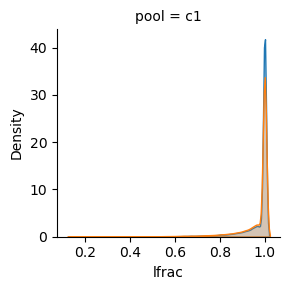

In [6]:
p1 = sns.FacetGrid(
    res_rs, col="pool", hue="prot", sharex=False, sharey=False
)
p1.map(sns.kdeplot, "lfrac", fill=True)
plt.show()

In [7]:
res_c1 = (
    res_rs
        # filter c1
        .query("pool == 'c1'")  
        # truncation degree
        .assign(
            is_truncated=lambda d: d["lfrac"] < 0.95,
        )
        # aggregate truncated
        .groupby(["prot", "ref_id"])
        .agg(
            total_alignments=("lfrac", "count"),
            truncated_alignments=("is_truncated", "sum"),
        )
        # frac truncated
        .assign(
            pct_truncated=lambda d: 100
            * d["truncated_alignments"]
            / d["total_alignments"]
        )
        # mean over pct 
        .groupby(["prot", "ref_id"])
        .agg(mean_truncated_alignments=("pct_truncated", "mean"))
        .reset_index()
        # to wide format
        .pivot(
            index="ref_id",
            columns="prot",
            values="mean_truncated_alignments",
        )
        # difference in truncated sequences
        .assign(
            diff=lambda d: d["ns"] - d["hp"],
            ref_id=lambda d: d.index
        )
)

In [9]:
#res_c1.to_csv(
#    f"../results/c1_diff_trunc.csv", index=False
#)

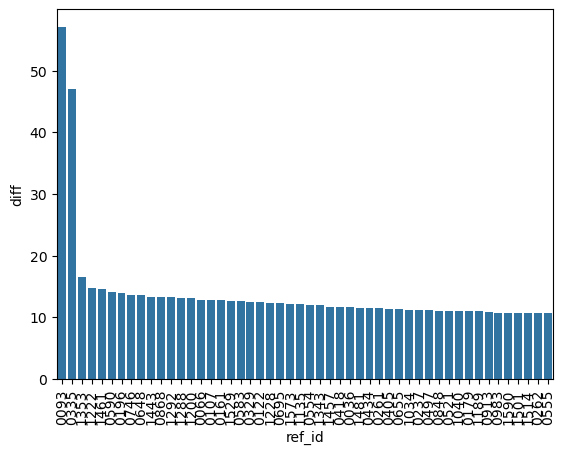

In [11]:
res_c1_diff = (
    res_c1
    .sort_values(by="diff", key=lambda s: s.abs(), ascending=False)
    .head(50)
)

p1 = sns.barplot(
    res_c1_diff,
    x='ref_id',
    y='diff'
)
plt.xticks(rotation=90, ha="center")
plt.show()

In [12]:
# coverage per position
cov_tb = (
    res_rs
      .query("pool == 'c1' and ref_id in ['0093','0335']")
      .assign(pos=lambda d: d["width"].apply(lambda w: range(1, int(w)+1)))
      .explode("pos")
      .groupby(["prot", "ref_id", "pos"], sort=False).size().rename("count").reset_index()
      .pipe(lambda d: (
          pd.MultiIndex.from_product(
              [d.prot.unique(), d.ref_id.unique(), range(1, 141)],
              names=["prot", "ref_id", "pos"]
          ).to_frame(index=False)
          .merge(d, how="left").fillna({"count": 0})
      ))
)

In [13]:
#cov_tb.to_csv(
#    f"../results/c1_diff_trunc_cov.csv", index=False
#)

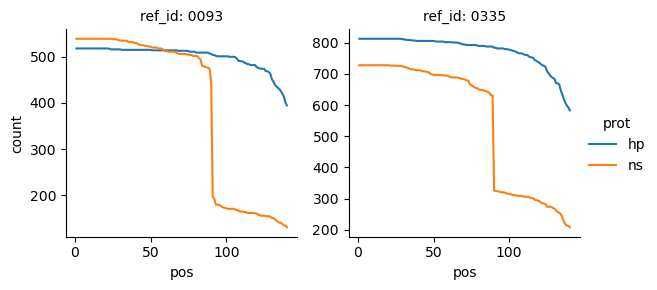

In [14]:
# plot
p3 = sns.relplot(
    cov_tb,
    x = "pos",
    y = "count",
    hue = "prot",
    col = "ref_id",
    kind = "line",
    facet_kws = dict(sharey=False),
    height=3, aspect=1
)

p3.set_titles("ref_id: {col_name}")
plt.show()

In [15]:
def largest_drop(sub):
    s = sub.sort_values("pos")["count"]
    drops = (s.shift(1) - s).fillna(0)
    idx = drops.idxmax()
    return sub.loc[idx, ["pos","count"]].rename({"pos":"drop_pos","count":"count_after"})

drop_tbl = (
    cov_tb
      .groupby(["prot", "ref_id"], sort=False)
      .apply(largest_drop, include_groups=False)
      .reset_index()
)

fa = pysam.FastaFile(ref_c1)

drop_tbl["motif"] = drop_tbl.apply(
    lambda r: fa.fetch(
        r.ref_id,
        max(r.drop_pos - 1 - 7, 0),
        r.drop_pos + 7
    ),
    axis=1
)
fa.close()

print(drop_tbl)
print('GGATG|CATCC')

  prot ref_id  drop_pos  count_after            motif
0   hp   0093       139          401        TAATTACGG
1   hp   0335       134          648   TGCTCTCCATTCTC
2   ns   0093        91          196  AGTGAGCTATCTTTA
3   ns   0335        90          326  TTGCTCACCCGGTTC
GGATG|CATCC


In [16]:
rs_dict = {
    "GGATG": re.compile(r'(GGATG){s<=5,i<=0,d<=0}'),
    "CATCC": re.compile(r'(CATCC){s<=5,i<=0,d<=0}')
}

def best_hit(seq: str):
    
    best_sub, best_pat, best_edits = None, None, 5

    for pat_name, pat in rs_dict.items():
        for m in pat.finditer(seq, overlapped=True):
            subs = m.fuzzy_counts[0]
            if subs < best_edits:
                best_sub = m.group(1)
                best_pat = pat_name
                best_edits = subs
                if best_edits == 0:
                    return best_sub, best_pat, 0
    return best_sub, best_pat, best_edits

df = (
    drop_tbl
    .query("prot == 'ns'")
    .copy()
)

df[["best_5mer", "matched_query", "edits"]] = (
    df["motif"]
      .apply(best_hit)
      .apply(pd.Series, index=["best_5mer", "matched_query", "edits"])
)

df["similarity"] = (5 - df["edits"]) / 5
df

,prot,ref_id,drop_pos,count_after,motif,best_5mer,matched_query,edits,similarity
2,ns,0093,91,196,AGTGAGCTATCTTTA,TATCT,CATCC,2,0.6
3,ns,0335,90,326,TTGCTCACCCGGTTC,CACCC,CATCC,1,0.8


In [17]:
# count mapped reads
def count_primary_alignments_bam(bam_dict, ref, out):

    # get all ref ids
    fasta = pysam.FastaFile(ref)
    ref_ids = pd.DataFrame({"ref_id": fasta.references})
    fasta.close()

    # init list
    data = []

    # iterate over bams
    for name, bam_file in bam_dict.items():
        # open bam
        bam = pysam.AlignmentFile(bam_file, "rb")
        
        # iterate through each read
        for read in bam:
            # check if the read is primary
            if read.is_mapped and not read.is_secondary:
                # get info
                ref_id = bam.get_reference_name(read.reference_id)
                width = read.reference_end - read.reference_start
                nm = read.get_tag("NM") if read.has_tag("NM") else None
                
                # append to the list
                data.append((name, ref_id, width, nm))
        
        bam.close()
    
    # to dataframe
    df = pd.DataFrame(data, columns=["name", "ref_id", "width", "nm"])

    # count occurrences
    grouped_df = (
        df.groupby(["name", "ref_id", "width", "nm"])
        .size()
        .reset_index(name="count")
    )

    # cartesian of all bam names and reference IDs
    names = pd.DataFrame({"name": list(bam_dict.keys())})
    ref_cartesian = pd.merge(names, ref_ids, how="cross")

    # merge dataframes
    res = pd.merge(
        ref_cartesian,
        grouped_df,
        on=["name", "ref_id"],
        how="left"
    )

    # fill NaN values for counts
    res["count"] = res["count"].fillna(0).astype(int)
    
    # write to parquet
    if out and not res.empty:
        res.to_parquet(out, index=False)
        
    #return res


In [18]:
count_primary_alignments_bam(
    {k: v for k, v in bams.items() if re.search(r"f1$", k)},
    ref = ref_f1,
    out = "../results/read_stats_summ_f1.parquet"
)
count_primary_alignments_bam(
    {k: v for k, v in bams.items() if re.search(r"p2$", k)},
    ref = ref_p2,
    out = "../results/read_stats_summ_p2.parquet"
)
count_primary_alignments_bam(
    {k: v for k, v in bams.items() if re.search(r"c1$", k)},
    ref = ref_c1,    
    out = "../results/read_stats_summ_c1.parquet"
)

In [19]:
query = """
SELECT
    name,
    split_part(name, '_', 1) AS prot,
    split_part(name, '_', 2) AS pool,
    ref_id,
    SUM("count")             AS n_mapped
FROM '../results/read_stats_summ_*.parquet'
WHERE (nm < 4 AND width > 136)
      OR "count" = 0
GROUP BY name, prot, pool, ref_id
"""

res_al = duckdb.query(query).fetchdf()

# res_al = (
#     res_al
#     .loc[lambda df: ((df['nm'] < 4) & (df['width'] > 136)) | (df['count'] == 0)]
#     .groupby(['name', 'ref_id'], as_index=False)
#     .agg(n_mapped=('count', 'sum'))
#     .assign(
#         prot=lambda d: d['bam_name'].str.split('_').str[0],
#         pool=lambda d: d['bam_name'].str.split('_').str[1],
#     )
# )

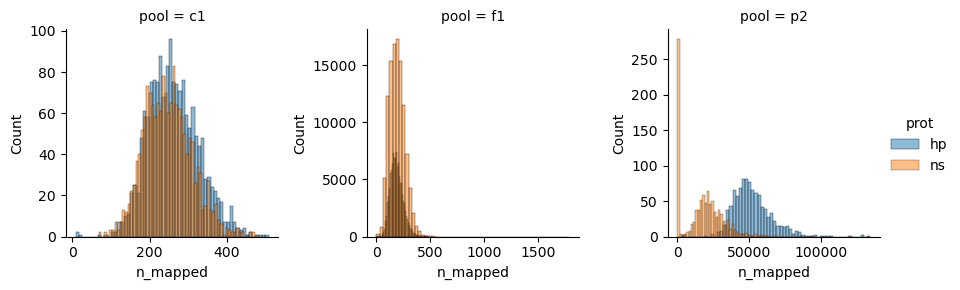

In [20]:
p4 = sns.FacetGrid(
    res_al,
    col="pool",
    hue="prot",
    sharex=False,
    sharey=False
)
p4.map_dataframe(
    sns.histplot, x="n_mapped", multiple="layer", alpha=0.5, bins = 60
    #sns.kdeplot, x="n_mapped", multiple="layer", alpha=0.5,
)
p4.add_legend()
plt.show()

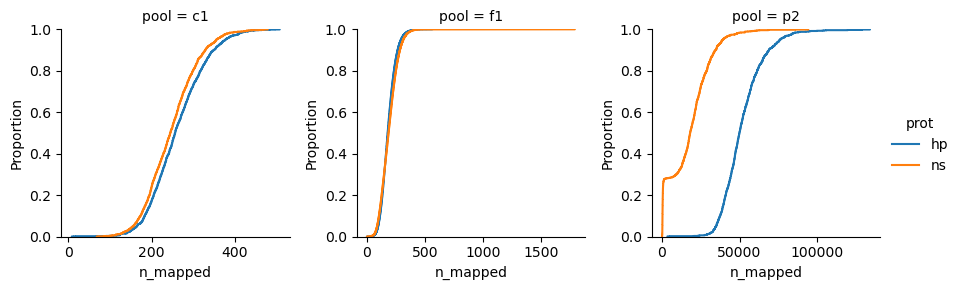

In [21]:
p5 = sns.FacetGrid(
    res_al,
    col="pool",
    hue="prot",
    sharex=False,
    sharey=False
)
p5.map_dataframe(
    sns.ecdfplot,
    x="n_mapped"
)
p5.add_legend()
plt.show()